# 22 - Alternative Texture Features (LBP, Gabor, Laws')

Extract 3 families of texture features not covered by PyRadiomics and test whether they
discriminate rejection from non-rejection. This addresses the concern: "maybe we used
the wrong features."

**Feature families:**
- LBP (Local Binary Patterns): 54 features (3 radius configs x histogram bins)
- Gabor filters: 54 features (3 frequencies x 6 orientations x 3 stats)
- Laws' texture energy: 45 features (15 kernel pairs x 3 stats)
- Total: 153 new features per image

**Analysis pipeline (same as NB 19/20):**
1. Extract all 153 features from 137 studies
2. Statistical testing on full dataset (137 studies) + independent dataset (55 studies)
3. ML classification on independent dataset (10-fold stratified CV)

**Expected outcome:** Negative (no signal), which strengthens the thesis conclusion that
the limitation is fundamental, not methodological.

In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import pydicom
from scipy.signal import convolve2d
from scipy import stats
from skimage.feature import local_binary_pattern
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("Imports OK")

Imports OK


In [2]:
raw_folder = os.path.join("..", "data", "PANCREAS_2", "PANCREAS_2")
mask_folder = os.path.join("..", "data", "PANCREAS_PREPROCESSED_CONTOUR_SUBTRACTED_ERODED_K3_I1", "masks")

df_full = pd.read_csv(os.path.join("reports", "13_merged_radiomics_clinical.csv"))
study_ids = df_full["study_id"].tolist()
print(f"Studies to process: {len(study_ids)}")


def load_grayscale_and_mask(study_id):
    """Load DICOM as grayscale numpy array + binary mask."""
    patient_folder = os.path.join(raw_folder, study_id)
    subfolders = [f for f in os.listdir(patient_folder) if not f.startswith(".")]
    date_folder = os.path.join(patient_folder, subfolders[0])
    files = [f for f in os.listdir(date_folder) if not f.startswith(".")]
    dicom_path = os.path.join(date_folder, files[0])

    ds = pydicom.dcmread(dicom_path)
    pixels = ds.pixel_array
    if len(pixels.shape) == 3:
        gray = cv2.cvtColor(pixels, cv2.COLOR_RGB2GRAY)
    else:
        gray = pixels

    mask_path = os.path.join(mask_folder, f"{study_id}_mask_eroded_k3_i1.png")
    mask_raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask_binary = (mask_raw > 0).astype(np.uint8)

    if gray.shape != mask_binary.shape:
        mask_binary = cv2.resize(mask_binary, (gray.shape[1], gray.shape[0]),
                                 interpolation=cv2.INTER_NEAREST)

    return gray, mask_binary


# Quick test
gray_test, mask_test = load_grayscale_and_mask(study_ids[0])
print(f"Test image shape: {gray_test.shape}, dtype: {gray_test.dtype}")
print(f"Test mask shape: {mask_test.shape}, pixels in ROI: {mask_test.sum()}")

Studies to process: 137
Test image shape: (768, 1024), dtype: uint8
Test mask shape: (768, 1024), pixels in ROI: 18299


## LBP (Local Binary Patterns)

Encodes local micro-patterns by comparing each pixel to its circular neighborhood.
Using "uniform" method: classifies patterns as uniform (at most 2 bitwise transitions)
or non-uniform. Histogram of pattern types is the feature vector.

- R=1, P=8: fine texture (10 bins)
- R=2, P=16: medium texture (18 bins)
- R=3, P=24: coarse texture (26 bins)

In [3]:
LBP_CONFIGS = [
    {"radius": 1, "n_points": 8},
    {"radius": 2, "n_points": 16},
    {"radius": 3, "n_points": 24},
]


def extract_lbp_features(gray, mask):
    """Extract LBP histogram features from masked region."""
    features = {}
    for cfg in LBP_CONFIGS:
        radius = cfg["radius"]
        n_points = cfg["n_points"]
        n_bins = n_points + 2

        lbp_image = local_binary_pattern(gray, n_points, radius, method="uniform")
        lbp_masked = lbp_image[mask > 0]

        hist, _ = np.histogram(lbp_masked, bins=n_bins, range=(0, n_bins), density=True)

        for bin_idx in range(n_bins):
            features[f"lbp_r{radius}_p{n_points}_bin{bin_idx}"] = hist[bin_idx]

    return features


# Test
lbp_test = extract_lbp_features(gray_test, mask_test)
print(f"LBP features: {len(lbp_test)}")
print(f"First 5: {list(lbp_test.items())[:5]}")

LBP features: 54
First 5: [('lbp_r1_p8_bin0', np.float64(0.008579703808951308)), ('lbp_r1_p8_bin1', np.float64(0.04890977649051861)), ('lbp_r1_p8_bin2', np.float64(0.0433903491994098)), ('lbp_r1_p8_bin3', np.float64(0.1484234111153615)), ('lbp_r1_p8_bin4', np.float64(0.3424777310235532))]


## Gabor Filters

Responds to texture at specific frequencies and orientations. Each filter is a
sinusoidal wave modulated by a Gaussian envelope. We compute the magnitude response
and extract mean, std, and energy from the masked region.

- 3 wavelengths (lambda): 5, 10, 20 pixels
- 6 orientations: 0, 30, 60, 90, 120, 150 degrees
- 3 stats per response: mean, std, energy

In [4]:
GABOR_WAVELENGTHS = [5, 10, 20]
GABOR_ORIENTATIONS = [0, 30, 60, 90, 120, 150]


def extract_gabor_features(gray, mask):
    """Extract Gabor filter response statistics from masked region."""
    features = {}
    gray_float = gray.astype(np.float64)

    for wavelength in GABOR_WAVELENGTHS:
        for angle_deg in GABOR_ORIENTATIONS:
            theta = np.deg2rad(angle_deg)
            sigma = 0.56 * wavelength
            kernel_size = int(6 * sigma) | 1  # ensure odd

            kernel = cv2.getGaborKernel(
                ksize=(kernel_size, kernel_size),
                sigma=sigma,
                theta=theta,
                lambd=wavelength,
                gamma=0.5,
                psi=0
            )

            response = cv2.filter2D(gray_float, cv2.CV_64F, kernel)
            vals = np.abs(response[mask > 0])

            label = f"gabor_w{wavelength}_o{angle_deg}"
            features[f"{label}_mean"] = float(np.mean(vals))
            features[f"{label}_std"] = float(np.std(vals))
            features[f"{label}_energy"] = float(np.mean(vals ** 2))

    return features


# Test
gabor_test = extract_gabor_features(gray_test, mask_test)
print(f"Gabor features: {len(gabor_test)}")
print(f"First 5: {list(gabor_test.items())[:5]}")

Gabor features: 54
First 5: [('gabor_w5_o0_mean', 29.36790238511151), ('gabor_w5_o0_std', 86.65819919493093), ('gabor_w5_o0_energy', 8372.117178209766), ('gabor_w5_o30_mean', 37.848303604618586), ('gabor_w5_o30_std', 81.68875943399485)]


## Laws' Texture Energy Measures

Detects texture energy using predefined 1D kernels (Level, Edge, Spot, Ripple, Wave)
combined into 2D via outer product. 15 unique combinations (upper triangle of 5x5).
Stats from masked region: mean, std, energy.

In [5]:
LAWS_KERNELS = {
    "L5": np.array([1, 4, 6, 4, 1], dtype=np.float64),
    "E5": np.array([-1, -2, 0, 2, 1], dtype=np.float64),
    "S5": np.array([-1, 0, 2, 0, -1], dtype=np.float64),
    "R5": np.array([1, -4, 6, -4, 1], dtype=np.float64),
    "W5": np.array([-1, 2, 0, -2, 1], dtype=np.float64),
}


def extract_laws_features(gray, mask):
    """Extract Laws' texture energy features from masked region."""
    features = {}
    gray_float = gray.astype(np.float64)
    kernel_names = list(LAWS_KERNELS.keys())

    for i in range(len(kernel_names)):
        for j in range(i, len(kernel_names)):
            name_row = kernel_names[i]
            name_col = kernel_names[j]

            kernel_2d = np.outer(LAWS_KERNELS[name_row], LAWS_KERNELS[name_col])
            response = convolve2d(gray_float, kernel_2d, mode="same", boundary="symm")

            vals = np.abs(response[mask > 0])

            label = f"laws_{name_row}{name_col}"
            features[f"{label}_mean"] = float(np.mean(vals))
            features[f"{label}_std"] = float(np.std(vals))
            features[f"{label}_energy"] = float(np.mean(vals ** 2))

    return features


# Test
laws_test = extract_laws_features(gray_test, mask_test)
print(f"Laws' features: {len(laws_test)}")
print(f"First 5: {list(laws_test.items())[:5]}")

Laws' features: 45
First 5: [('laws_L5L5_mean', 11650.25465872452), ('laws_L5L5_std', 4045.944004324561), ('laws_L5L5_energy', 152098096.49926224), ('laws_L5E5_mean', 263.55068582982676), ('laws_L5E5_std', 497.2995409950624)]


## Extract all features from 137 studies

In [6]:
all_features = []
failed_studies = []

for idx, study_id in enumerate(study_ids):
    if (idx + 1) % 10 == 0:
        print(f"Processing {idx + 1}/{len(study_ids)}...")

    try:
        gray, mask = load_grayscale_and_mask(study_id)

        lbp_feats = extract_lbp_features(gray, mask)
        gabor_feats = extract_gabor_features(gray, mask)
        laws_feats = extract_laws_features(gray, mask)

        row = {"study_id": study_id}
        row.update(lbp_feats)
        row.update(gabor_feats)
        row.update(laws_feats)
        all_features.append(row)

    except Exception as e:
        print(f"  FAILED {study_id}: {e}")
        failed_studies.append(study_id)

print(f"\nDone. Extracted: {len(all_features)}, Failed: {len(failed_studies)}")
if failed_studies:
    print(f"Failed studies: {failed_studies}")

Processing 10/137...


Processing 20/137...


Processing 30/137...


Processing 40/137...


Processing 50/137...


...

Processing 100/137...


Processing 110/137...


Processing 120/137...


Processing 130/137...



Done. Extracted: 137, Failed: 0


In [7]:
features_df = pd.DataFrame(all_features)
feature_cols = [c for c in features_df.columns if c != "study_id"]
print(f"Feature matrix: {features_df.shape[0]} studies x {len(feature_cols)} features")
print(f"  LBP: {len([c for c in feature_cols if c.startswith('lbp_')])}")
print(f"  Gabor: {len([c for c in feature_cols if c.startswith('gabor_')])}")
print(f"  Laws: {len([c for c in feature_cols if c.startswith('laws_')])}")

# Merge with labels
labels = df_full[["study_id", "patient_id", "rejection"]]
features_with_labels = pd.merge(features_df, labels, on="study_id")
print(f"\nAfter merge with labels: {len(features_with_labels)} rows")

# Save
output_path = os.path.join("reports", "22_alternative_features.csv")
features_with_labels.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Feature matrix: 137 studies x 153 features
  LBP: 54
  Gabor: 54
  Laws: 45

After merge with labels: 137 rows
Saved to reports/22_alternative_features.csv


## Statistical analysis - full dataset (137 studies)

Same approach as NB 14a/19: Shapiro-Wilk for normality, then t-test or Mann-Whitney U,
followed by Benjamini-Hochberg FDR correction.

In [8]:
rejection = features_with_labels[features_with_labels["rejection"] == 1]
no_rejection = features_with_labels[features_with_labels["rejection"] == 0]

print(f"Full dataset: {len(no_rejection)} no-rej, {len(rejection)} rej")

test_results_full = []

for feat in feature_cols:
    vals_no_rej = no_rejection[feat].dropna().values
    vals_rej = rejection[feat].dropna().values

    _, p_no_rej = stats.shapiro(vals_no_rej)
    _, p_rej = stats.shapiro(vals_rej)
    both_normal = (p_no_rej > 0.05) and (p_rej > 0.05)

    if both_normal:
        stat, p_value = stats.ttest_ind(vals_no_rej, vals_rej, equal_var=False)
        test_name = "t-test"
        pooled_std = np.sqrt(
            ((len(vals_no_rej) - 1) * vals_no_rej.std(ddof=1)**2 +
             (len(vals_rej) - 1) * vals_rej.std(ddof=1)**2) /
            (len(vals_no_rej) + len(vals_rej) - 2)
        )
        effect_size = (vals_rej.mean() - vals_no_rej.mean()) / pooled_std if pooled_std > 0 else 0.0
    else:
        stat, p_value = stats.mannwhitneyu(vals_no_rej, vals_rej, alternative="two-sided")
        test_name = "Mann-Whitney"
        n1 = len(vals_no_rej)
        n2 = len(vals_rej)
        effect_size = 1 - (2 * stat) / (n1 * n2)

    test_results_full.append({
        "feature": feat,
        "test": test_name,
        "statistic": stat,
        "p_value": p_value,
        "effect_size": effect_size,
        "mean_no_rej": vals_no_rej.mean(),
        "mean_rej": vals_rej.mean(),
    })

results_full_df = pd.DataFrame(test_results_full).sort_values("p_value").reset_index(drop=True)

# FDR correction
reject_fdr, pvals_fdr, _, _ = multipletests(results_full_df["p_value"].values, alpha=0.05, method="fdr_bh")
results_full_df["p_value_fdr"] = pvals_fdr
results_full_df["significant_fdr"] = reject_fdr

n_sig_uncorrected = (results_full_df["p_value"] < 0.05).sum()
n_sig_fdr = results_full_df["significant_fdr"].sum()
print(f"\nFull dataset (137 studies):")
print(f"  Uncorrected p < 0.05: {n_sig_uncorrected}/{len(feature_cols)}")
print(f"  FDR-corrected p < 0.05: {n_sig_fdr}/{len(feature_cols)}")
print(f"\nTop 10 features:")
print(results_full_df[["feature", "test", "p_value", "p_value_fdr", "effect_size"]].head(10).to_string(index=False))

Full dataset: 98 no-rej, 39 rej

Full dataset (137 studies):
  Uncorrected p < 0.05: 5/153
  FDR-corrected p < 0.05: 0/153

Top 10 features:
           feature         test  p_value  p_value_fdr  effect_size
   lbp_r3_p24_bin6       t-test 0.014289     0.601752     0.464508
gabor_w10_o150_std Mann-Whitney 0.036051     0.601752     0.230246
  lbp_r3_p24_bin18       t-test 0.040258     0.601752     0.392552
  lbp_r3_p24_bin25       t-test 0.046727     0.601752    -0.363751
 gabor_w5_o90_mean Mann-Whitney 0.048571     0.601752    -0.216641
 gabor_w5_o150_std Mann-Whitney 0.052508     0.601752     0.212977
  lbp_r3_p24_bin16       t-test 0.059058     0.601752     0.357060
    lbp_r1_p8_bin7       t-test 0.059196     0.601752    -0.336743
  lbp_r3_p24_bin20       t-test 0.059731     0.601752     0.328392
   lbp_r3_p24_bin7       t-test 0.060872     0.601752     0.357240


In [9]:
results_full_df.to_csv(os.path.join("reports", "22_stats_full_dataset.csv"), index=False)
print("Saved to reports/22_stats_full_dataset.csv")

Saved to reports/22_stats_full_dataset.csv


## Statistical analysis - independent dataset (55 studies)

Filter to the 55 independent studies (1 per patient) and repeat.

In [10]:
indep_df = pd.read_csv(os.path.join("reports", "18_independent_dataset.csv"))
indep_ids = indep_df["study_id"].tolist()

features_indep = features_with_labels[features_with_labels["study_id"].isin(indep_ids)].copy()
rejection_indep = features_indep[features_indep["rejection"] == 1]
no_rejection_indep = features_indep[features_indep["rejection"] == 0]

print(f"Independent dataset: {len(features_indep)} studies ({len(no_rejection_indep)} no-rej, {len(rejection_indep)} rej)")

test_results_indep = []

for feat in feature_cols:
    vals_no_rej = no_rejection_indep[feat].dropna().values
    vals_rej = rejection_indep[feat].dropna().values

    _, p_no_rej = stats.shapiro(vals_no_rej)
    _, p_rej = stats.shapiro(vals_rej)
    both_normal = (p_no_rej > 0.05) and (p_rej > 0.05)

    if both_normal:
        stat, p_value = stats.ttest_ind(vals_no_rej, vals_rej, equal_var=False)
        test_name = "t-test"
        pooled_std = np.sqrt(
            ((len(vals_no_rej) - 1) * vals_no_rej.std(ddof=1)**2 +
             (len(vals_rej) - 1) * vals_rej.std(ddof=1)**2) /
            (len(vals_no_rej) + len(vals_rej) - 2)
        )
        effect_size = (vals_rej.mean() - vals_no_rej.mean()) / pooled_std if pooled_std > 0 else 0.0
    else:
        stat, p_value = stats.mannwhitneyu(vals_no_rej, vals_rej, alternative="two-sided")
        test_name = "Mann-Whitney"
        n1 = len(vals_no_rej)
        n2 = len(vals_rej)
        effect_size = 1 - (2 * stat) / (n1 * n2)

    test_results_indep.append({
        "feature": feat,
        "test": test_name,
        "statistic": stat,
        "p_value": p_value,
        "effect_size": effect_size,
        "mean_no_rej": vals_no_rej.mean(),
        "mean_rej": vals_rej.mean(),
    })

results_indep_df = pd.DataFrame(test_results_indep).sort_values("p_value").reset_index(drop=True)

# FDR correction
reject_fdr, pvals_fdr, _, _ = multipletests(results_indep_df["p_value"].values, alpha=0.05, method="fdr_bh")
results_indep_df["p_value_fdr"] = pvals_fdr
results_indep_df["significant_fdr"] = reject_fdr

n_sig_uncorrected = (results_indep_df["p_value"] < 0.05).sum()
n_sig_fdr = results_indep_df["significant_fdr"].sum()
print(f"\nIndependent dataset (55 studies):")
print(f"  Uncorrected p < 0.05: {n_sig_uncorrected}/{len(feature_cols)}")
print(f"  FDR-corrected p < 0.05: {n_sig_fdr}/{len(feature_cols)}")
print(f"\nTop 10 features:")
print(results_indep_df[["feature", "test", "p_value", "p_value_fdr", "effect_size"]].head(10).to_string(index=False))

Independent dataset: 55 studies (34 no-rej, 21 rej)

Independent dataset (55 studies):
  Uncorrected p < 0.05: 7/153
  FDR-corrected p < 0.05: 0/153

Top 10 features:
          feature         test  p_value  p_value_fdr  effect_size
   laws_L5W5_mean Mann-Whitney 0.020736     0.536253    -0.375350
  lbp_r2_p16_bin9       t-test 0.037195     0.536253     0.557626
   laws_E5W5_mean Mann-Whitney 0.040083     0.536253    -0.333333
 laws_E5E5_energy Mann-Whitney 0.041794     0.536253    -0.330532
   laws_E5S5_mean Mann-Whitney 0.047301     0.536253    -0.322129
   laws_L5R5_mean Mann-Whitney 0.049267     0.536253    -0.319328
gabor_w5_o30_mean Mann-Whitney 0.049267     0.536253    -0.319328
   laws_R5R5_mean Mann-Whitney 0.051302     0.536253    -0.316527
   laws_L5S5_mean       t-test 0.051559     0.536253    -0.588819
   laws_E5E5_mean       t-test 0.057452     0.536253    -0.566196


In [11]:
results_indep_df.to_csv(os.path.join("reports", "22_stats_independent_dataset.csv"), index=False)
print("Saved to reports/22_stats_independent_dataset.csv")

Saved to reports/22_stats_independent_dataset.csv


## ML classification - independent dataset (10-fold stratified CV)

Same pipeline as NB 20: correlation removal, StandardScaler, SelectKBest, 4 models.
Joint optimization over feature count (k) and hyperparameters.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.base import clone

print("ML imports OK")

ML imports OK


In [13]:
# Prepare ML data from independent dataset
X_all = features_indep[feature_cols].values
y = features_indep["rejection"].values

# Correlation removal (same approach as NB 20)
p_values = dict(zip(results_indep_df["feature"], results_indep_df["p_value"]))
corr = features_indep[feature_cols].corr().abs()

to_drop = set()
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        if corr.iloc[i, j] > 0.9:
            fi, fj = feature_cols[i], feature_cols[j]
            if fi in to_drop or fj in to_drop:
                continue
            if p_values.get(fi, 1.0) <= p_values.get(fj, 1.0):
                to_drop.add(fj)
            else:
                to_drop.add(fi)

reduced_features = [f for f in feature_cols if f not in to_drop]
X = features_indep[reduced_features].values

print(f"Features: {len(feature_cols)} -> {len(reduced_features)} after correlation removal")
print(f"X shape: {X.shape}, y: {(y == 0).sum()} no-rej, {(y == 1).sum()} rej")

Features: 153 -> 68 after correlation removal
X shape: (55, 68), y: 34 no-rej, 21 rej


In [14]:
n_features = X.shape[1]
k_values = [5, 10, 15, 20, min(30, n_features)]
k_values = sorted(set([k for k in k_values if k <= n_features]))


def make_pipe(model):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif)),
        ("model", model),
    ])


pipelines = {
    "LogReg": {
        "pipe": make_pipe(LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
        "grid": {"select__k": k_values, "model__C": [0.01, 0.1, 1.0, 10.0]},
    },
    "RF": {
        "pipe": make_pipe(RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)),
        "grid": {"select__k": k_values, "model__max_depth": [3, 5, 7], "model__min_samples_leaf": [3, 5, 10]},
    },
    "SVM": {
        "pipe": make_pipe(SVC(probability=True, class_weight="balanced", random_state=42)),
        "grid": {"select__k": k_values, "model__C": [0.1, 1.0, 10.0], "model__kernel": ["linear", "rbf"]},
    },
    "NaiveBayes": {
        "pipe": make_pipe(GaussianNB()),
        "grid": {"select__k": k_values, "model__var_smoothing": [1e-9, 1e-7, 1e-5]},
    },
}

print(f"k values: {k_values}")
for name, spec in pipelines.items():
    n_combos = 1
    for vals in spec["grid"].values():
        n_combos *= len(vals)
    print(f"  {name}: {n_combos} combinations")

k values: [5, 10, 15, 20, 30]
  LogReg: 20 combinations
  RF: 45 combinations
  SVM: 30 combinations
  NaiveBayes: 15 combinations


In [15]:
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_outer = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

ml_results = []
cv10_probas = {}

for name, spec in pipelines.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")

    gs = GridSearchCV(spec["pipe"], spec["grid"], cv=cv_inner, scoring="roc_auc", n_jobs=-1)
    gs.fit(X, y)
    print(f"  Best inner CV AUC: {gs.best_score_:.3f}")
    print(f"  Best params: {gs.best_params_}")

    best_pipe = gs.best_estimator_
    y_proba = cross_val_predict(
        clone(best_pipe), X, y, cv=cv_outer, method="predict_proba"
    )[:, 1]

    auc = roc_auc_score(y, y_proba)
    fpr, tpr, thresholds = roc_curve(y, y_proba)
    J = tpr - fpr
    best_idx = np.argmax(J)

    print(f"  10-fold CV AUC: {auc:.3f}")
    print(f"  Sensitivity: {tpr[best_idx]:.3f}  Specificity: {1 - fpr[best_idx]:.3f}")

    cv10_probas[name] = {"y_proba": y_proba, "fpr": fpr, "tpr": tpr, "auc": auc}

    ml_results.append({
        "model": name,
        "best_k": gs.best_params_["select__k"],
        "best_params": str({k: v for k, v in gs.best_params_.items() if k != "select__k"}),
        "cv10_auc": round(auc, 3),
        "sensitivity": round(tpr[best_idx], 3),
        "specificity": round(1 - fpr[best_idx], 3),
    })

ml_results_df = pd.DataFrame(ml_results)
print(f"\n\n{'='*60}")
print("SUMMARY - 10-fold stratified CV (independent dataset, alt features):")
print(f"{'='*60}")
print(ml_results_df.to_string(index=False))


LogReg


/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: Run

  Best inner CV AUC: 0.514
  Best params: {'model__C': 0.1, 'select__k': 30}
  10-fold CV AUC: 0.485
  Sensitivity: 0.190  Specificity: 0.912

RF


  Best inner CV AUC: 0.541
  Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 3, 'select__k': 5}


  10-fold CV AUC: 0.550
  Sensitivity: 0.762  Specificity: 0.412

SVM
  Best inner CV AUC: 0.583
  Best params: {'model__C': 1.0, 'model__kernel': 'rbf', 'select__k': 5}
  10-fold CV AUC: 0.468
  Sensitivity: 1.000  Specificity: 0.059

NaiveBayes
  Best inner CV AUC: 0.498
  Best params: {'model__var_smoothing': 1e-09, 'select__k': 30}
  10-fold CV AUC: 0.483
  Sensitivity: 0.857  Specificity: 0.265


SUMMARY - 10-fold stratified CV (independent dataset, alt features):
     model  best_k                                           best_params  cv10_auc  sensitivity  specificity
    LogReg      30                                     {'model__C': 0.1}     0.485        0.190        0.912
        RF       5 {'model__max_depth': 5, 'model__min_samples_leaf': 3}     0.550        0.762        0.412
       SVM       5             {'model__C': 1.0, 'model__kernel': 'rbf'}     0.468        1.000        0.059
NaiveBayes      30                       {'model__var_smoothing': 1e-09}     0.483        

In [16]:
rng = np.random.RandomState(42)
n_bootstrap = 1000
bootstrap_rows = []

for name, res in cv10_probas.items():
    y_proba = res["y_proba"]
    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.randint(0, len(y), len(y))
        if len(np.unique(y[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y[idx], y_proba[idx]))
    ci_lo = np.percentile(aucs, 2.5)
    ci_hi = np.percentile(aucs, 97.5)
    bootstrap_rows.append({
        "model": name,
        "cv10_auc": res["auc"],
        "ci_lower": round(ci_lo, 3),
        "ci_upper": round(ci_hi, 3),
    })
    print(f"{name:12s}  AUC={res['auc']:.3f}  95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")

bootstrap_df = pd.DataFrame(bootstrap_rows)

LogReg        AUC=0.485  95% CI [0.325, 0.657]


RF            AUC=0.550  95% CI [0.401, 0.709]


SVM           AUC=0.468  95% CI [0.307, 0.633]


NaiveBayes    AUC=0.483  95% CI [0.337, 0.636]


## ROC curves

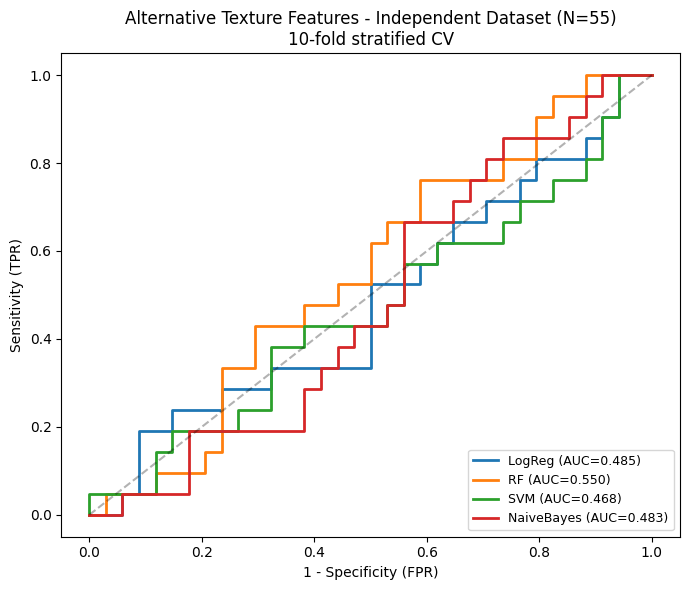

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for idx, (name, res) in enumerate(cv10_probas.items()):
    ax.plot(res["fpr"], res["tpr"], linewidth=2, color=colors[idx],
            label=f"{name} (AUC={res['auc']:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("1 - Specificity (FPR)")
ax.set_ylabel("Sensitivity (TPR)")
ax.set_title("Alternative Texture Features - Independent Dataset (N=55)\n10-fold stratified CV")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join("reports", "22_roc_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

## Comparison: PyRadiomics (93 features) vs alternative (153 features)

Side-by-side comparison of statistical and ML results.

In [18]:
# Load PyRadiomics results for comparison
pyrad_stats_full = pd.read_csv(os.path.join("reports", "14a_stats_radiomics_features.csv"))
pyrad_stats_indep = pd.read_csv(os.path.join("reports", "19_stats_independent_dataset.csv"))
pyrad_ml = pd.read_csv(os.path.join("reports", "20_ml_independent_dataset_results.csv"))

print("STATISTICAL COMPARISON")
print("=" * 60)
print(f"{'':30s}  {'PyRadiomics':>12s}  {'Alternative':>12s}")
print(f"{'-'*60}")
print(f"{'Features tested':30s}  {'93':>12s}  {str(len(feature_cols)):>12s}")

n_pyrad_full = (pyrad_stats_full["p_value"] < 0.05).sum()
n_alt_full = (results_full_df["p_value"] < 0.05).sum()
print(f"{'p<0.05 full (uncorrected)':30s}  {str(n_pyrad_full):>12s}  {str(n_alt_full):>12s}")

n_pyrad_indep = (pyrad_stats_indep["p_value"] < 0.05).sum()
n_alt_indep = (results_indep_df["p_value"] < 0.05).sum()
print(f"{'p<0.05 indep (uncorrected)':30s}  {str(n_pyrad_indep):>12s}  {str(n_alt_indep):>12s}")

n_pyrad_fdr = (pyrad_stats_full["p_value_fdr"] < 0.05).sum() if "p_value_fdr" in pyrad_stats_full.columns else 0
n_alt_fdr = results_full_df["significant_fdr"].sum()
print(f"{'Surviving FDR (full)':30s}  {str(n_pyrad_fdr):>12s}  {str(n_alt_fdr):>12s}")

print(f"\n\nML COMPARISON (independent dataset, 10-fold CV)")
print("=" * 60)
print(f"{'Model':12s}  {'PyRadiomics AUC':>16s}  {'Alternative AUC':>16s}")
print(f"{'-'*50}")
for _, row in ml_results_df.iterrows():
    pyrad_row = pyrad_ml[pyrad_ml["model"] == row["model"]]
    pyrad_auc = pyrad_row["cv10_auc"].values[0] if len(pyrad_row) > 0 else float("nan")
    print(f"{row['model']:12s}  {pyrad_auc:>16.3f}  {row['cv10_auc']:>16.3f}")

STATISTICAL COMPARISON
                                 PyRadiomics   Alternative
------------------------------------------------------------
Features tested                           93           153
p<0.05 full (uncorrected)                  0             5
p<0.05 indep (uncorrected)                 4             7
Surviving FDR (full)                       0             0


ML COMPARISON (independent dataset, 10-fold CV)
Model          PyRadiomics AUC   Alternative AUC
--------------------------------------------------
LogReg                   0.569             0.485
RF                       0.506             0.550
SVM                      0.283             0.468
NaiveBayes               0.508             0.483


In [19]:
# Save ML results
ml_save = pd.merge(ml_results_df, bootstrap_df[["model", "ci_lower", "ci_upper"]], on="model")
ml_save.to_csv(os.path.join("reports", "22_ml_results.csv"), index=False)
print("Saved to reports/22_ml_results.csv")
print()
print(ml_save.to_string(index=False))

Saved to reports/22_ml_results.csv

     model  best_k                                           best_params  cv10_auc  sensitivity  specificity  ci_lower  ci_upper
    LogReg      30                                     {'model__C': 0.1}     0.485        0.190        0.912     0.325     0.657
        RF       5 {'model__max_depth': 5, 'model__min_samples_leaf': 3}     0.550        0.762        0.412     0.401     0.709
       SVM       5             {'model__C': 1.0, 'model__kernel': 'rbf'}     0.468        1.000        0.059     0.307     0.633
NaiveBayes      30                       {'model__var_smoothing': 1e-09}     0.483        0.857        0.265     0.337     0.636


## Box plots of top features (by uncorrected p-value)

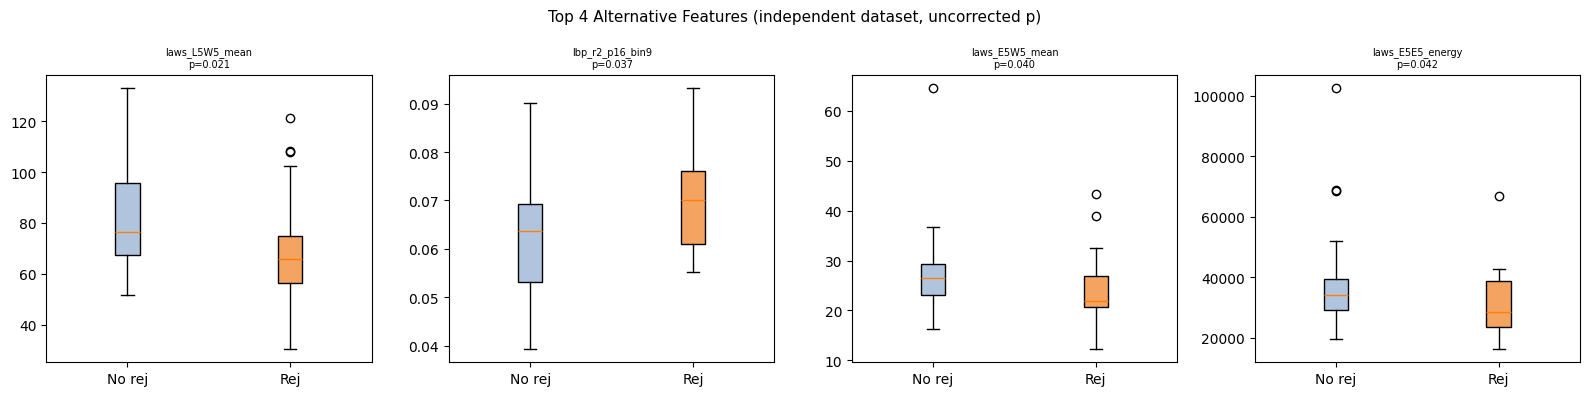

In [20]:
# Top 4 features from independent dataset stats
top4 = results_indep_df.head(4)["feature"].tolist()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(top4):
    data_no = no_rejection_indep[feat].values
    data_rej = rejection_indep[feat].values
    bp = axes[i].boxplot([data_no, data_rej], labels=["No rej", "Rej"], patch_artist=True)
    bp["boxes"][0].set_facecolor("#B0C4DE")
    bp["boxes"][1].set_facecolor("#F4A460")
    p_val = results_indep_df[results_indep_df["feature"] == feat]["p_value"].values[0]
    axes[i].set_title(f"{feat}\np={p_val:.3f}", fontsize=7)

plt.suptitle("Top 4 Alternative Features (independent dataset, uncorrected p)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join("reports", "22_boxplots_top_features.png"), dpi=150, bbox_inches="tight")
plt.show()

## Summary

In [21]:
print("NB 22 SUMMARY")
print("=" * 60)
print(f"Alternative features extracted: {len(feature_cols)}")
print(f"  LBP: {len([c for c in feature_cols if c.startswith('lbp_')])}")
print(f"  Gabor: {len([c for c in feature_cols if c.startswith('gabor_')])}")
print(f"  Laws: {len([c for c in feature_cols if c.startswith('laws_')])}")
print(f"")
print(f"Statistics (full dataset, 137 studies):")
print(f"  Uncorrected p < 0.05: {(results_full_df['p_value'] < 0.05).sum()}/{len(feature_cols)}")
print(f"  FDR-corrected p < 0.05: {results_full_df['significant_fdr'].sum()}/{len(feature_cols)}")
print(f"")
print(f"Statistics (independent, 55 studies):")
print(f"  Uncorrected p < 0.05: {(results_indep_df['p_value'] < 0.05).sum()}/{len(feature_cols)}")
print(f"  FDR-corrected p < 0.05: {results_indep_df['significant_fdr'].sum()}/{len(feature_cols)}")
print(f"")
print(f"ML (independent, 10-fold CV):")
for _, row in ml_results_df.iterrows():
    ci = bootstrap_df[bootstrap_df["model"] == row["model"]]
    ci_lo = ci["ci_lower"].values[0]
    ci_hi = ci["ci_upper"].values[0]
    print(f"  {row['model']:12s}  AUC={row['cv10_auc']:.3f}  [{ci_lo:.3f}, {ci_hi:.3f}]")
print(f"")
print(f"Output files:")
print(f"  reports/22_alternative_features.csv")
print(f"  reports/22_stats_full_dataset.csv")
print(f"  reports/22_stats_independent_dataset.csv")
print(f"  reports/22_ml_results.csv")
print(f"  reports/22_roc_curves.png")
print(f"  reports/22_boxplots_top_features.png")

NB 22 SUMMARY
Alternative features extracted: 153
  LBP: 54
  Gabor: 54
  Laws: 45

Statistics (full dataset, 137 studies):
  Uncorrected p < 0.05: 5/153
  FDR-corrected p < 0.05: 0/153

Statistics (independent, 55 studies):
  Uncorrected p < 0.05: 7/153
  FDR-corrected p < 0.05: 0/153

ML (independent, 10-fold CV):
  LogReg        AUC=0.485  [0.325, 0.657]
  RF            AUC=0.550  [0.401, 0.709]
  SVM           AUC=0.468  [0.307, 0.633]
  NaiveBayes    AUC=0.483  [0.337, 0.636]

Output files:
  reports/22_alternative_features.csv
  reports/22_stats_full_dataset.csv
  reports/22_stats_independent_dataset.csv
  reports/22_ml_results.csv
  reports/22_roc_curves.png
  reports/22_boxplots_top_features.png


## Interpretation

**Alternative texture features do not find signal that PyRadiomics missed.** Of 153 features (LBP, Gabor, Laws'), zero survive FDR correction on either dataset. The 5 and 7 uncorrected hits (full and independent datasets respectively) are well within what chance produces when testing 153 hypotheses (expected ~7.7 at alpha=0.05).

**ML performance is at or below chance.** The best model (RF, AUC=0.550) has a 95% CI of [0.401, 0.709] that comfortably includes 0.5. LogReg, SVM, and NaiveBayes all fall below 0.5. This is comparable to (and slightly worse than) the PyRadiomics results (best AUC 0.569). Neither feature set achieves useful classification.

**The top features differ between datasets.** Full dataset highlights LBP coarse-scale bins (r=3); independent dataset highlights Laws' kernels (L5W5, E5W5). This instability confirms these are noise, not signal.

**Conclusion.** Using fundamentally different texture descriptors (local micro-patterns, frequency/orientation content, and texture energy) does not rescue classification performance. This rules out "wrong features" as an explanation for the negative PyRadiomics result. The limitation is not in the feature extraction method but in the underlying data: B-mode grayscale ultrasound texture does not visibly change with rejection status.